# 00 — Daily Newsfeed Activity: Line Chart

## What this notebook does

Queries the `pageviews` table from the `checking-logs.sqlite` database
and visualizes how many times students visited the newsfeed each day
during the course.

## Data

- **Source:** `checking-logs.sqlite` → table `pageviews`
- **Filtered:** only real students (`uid LIKE 'user_%'`), excluding admins
- **Aggregation:** pageview counts grouped by date

## Key steps

1. Load pageview timestamps via SQL query
2. Convert `datetime` column to pandas datetime type
3. Extract date and count views per day with `value_counts()`
4. Plot a line chart with matplotlib

## Result

A line chart showing daily newsfeed activity across the entire course
period. Allows to spot peaks of student engagement — likely around
deadlines or after new content was published.

## Tools

`pandas` · `sqlite3` · `matplotlib`

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')

In [2]:
datetime = pd.read_sql("""
                      SELECT p.datetime
                      FROM pageviews AS p
                      WHERE p.uid LIKE 'user_%'
                      """,
                      conn)
datetime

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
...,...
982,2020-05-21 18:45:20.441142
983,2020-05-21 23:03:06.457819
984,2020-05-21 23:23:49.995349
985,2020-05-22 11:30:18.368990


In [3]:
datetime['datetime'] = pd.to_datetime(datetime['datetime'])
date = datetime['datetime'].dt.date
counts_date = date.value_counts().sort_index()
print(counts_date)
print(len(counts_date))


datetime
2020-04-17      1
2020-04-18     23
2020-04-19     15
2020-04-21      3
2020-04-22      1
2020-04-23      5
2020-04-25      1
2020-04-26      8
2020-04-28      2
2020-04-29      4
2020-04-30      9
2020-05-01      3
2020-05-02      6
2020-05-03     19
2020-05-04      1
2020-05-05      1
2020-05-06      3
2020-05-07      2
2020-05-08     48
2020-05-09     19
2020-05-10    110
2020-05-11    200
2020-05-12     85
2020-05-13    102
2020-05-14    187
2020-05-15     29
2020-05-16      4
2020-05-17      9
2020-05-18     51
2020-05-19     11
2020-05-20     12
2020-05-21     11
2020-05-22      2
Name: count, dtype: int64
33


<Axes: title={'center': 'Views per Day'}, xlabel='datetime'>

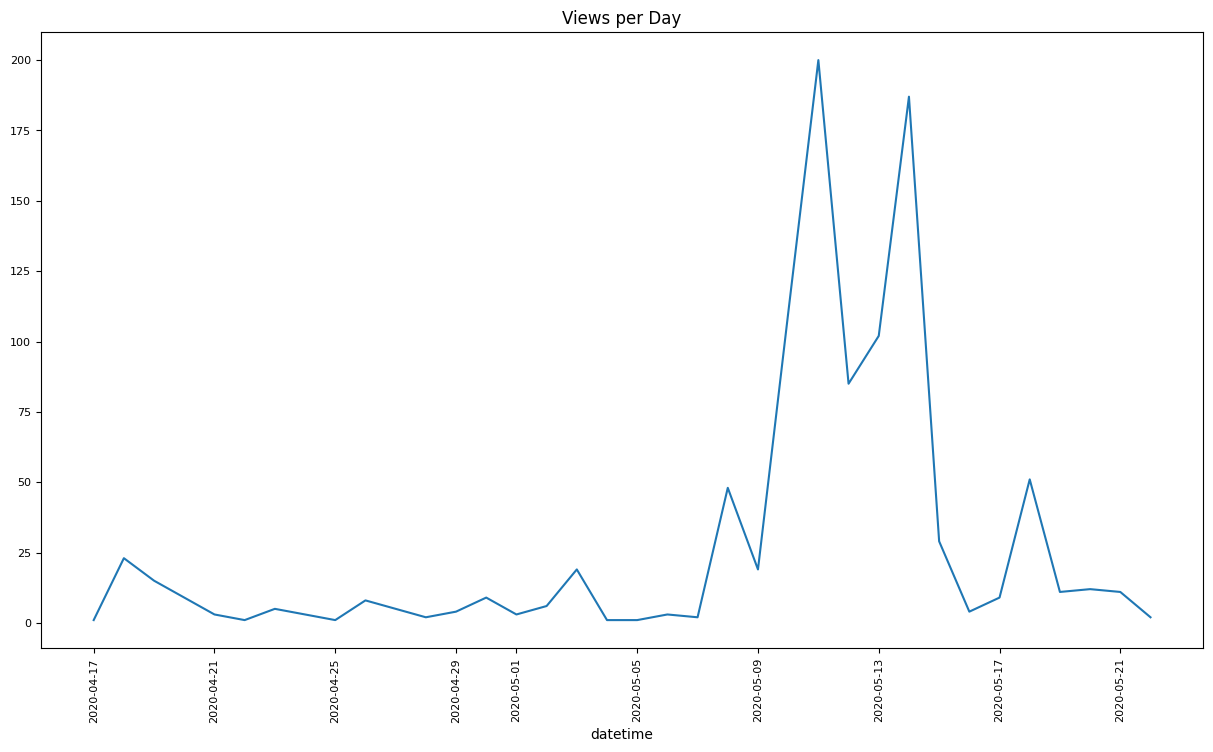

In [4]:
counts_date.plot(figsize=(15, 8), title="Views per Day", fontsize=8, rot=90)

In [5]:
conn.close()